In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [28]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [30]:
df = pd.read_csv(
    "/content/german.data-numeric",
    sep=r'\s+',
    header=None
)

print(df.head())

print(df.shape)
print(df.info())

   0   1   2   3   4   5   6   7   8   9   ...  15  16  17  18  19  20  21  \
0   1   6   4  12   5   5   3   4   1  67  ...   0   0   1   0   0   1   0   
1   2  48   2  60   1   3   2   2   1  22  ...   0   0   1   0   0   1   0   
2   4  12   4  21   1   4   3   3   1  49  ...   0   0   1   0   0   1   0   
3   1  42   2  79   1   4   3   4   2  45  ...   0   0   0   0   0   0   0   
4   1  24   3  49   1   3   3   4   4  53  ...   1   0   1   0   0   0   0   

   22  23  24  
0   0   1   1  
1   0   1   2  
2   1   0   1  
3   0   1   1  
4   0   1   2  

[5 rows x 25 columns]
(1000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       1000 non-null   int64
 1   1       1000 non-null   int64
 2   2       1000 non-null   int64
 3   3       1000 non-null   int64
 4   4       1000 non-null   int64
 5   5       1000 non-null   int64
 6   6       10

In [31]:
columns = [
    'CheckingStatus',
    'Duration',
    'CreditHistory',
    'Purpose',
    'CreditAmount',
    'Savings',
    'Employment',
    'InstallmentRate',
    'PersonalStatus',
    'OtherDebtors',
    'ResidenceSince',
    'Property',
    'Age',
    'OtherInstallment',
    'Housing',
    'ExistingCredits',
    'Job',
    'Dependents',
    'Telephone',
    'ForeignWorker',
    'A21',
    'A22',
    'A23',
    'A24',
    'Target'
]

df.columns = columns

In [4]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1349/1842323058.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1349/1842323058.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [32]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CheckingStatus    1000 non-null   int64
 1   Duration          1000 non-null   int64
 2   CreditHistory     1000 non-null   int64
 3   Purpose           1000 non-null   int64
 4   CreditAmount      1000 non-null   int64
 5   Savings           1000 non-null   int64
 6   Employment        1000 non-null   int64
 7   InstallmentRate   1000 non-null   int64
 8   PersonalStatus    1000 non-null   int64
 9   OtherDebtors      1000 non-null   int64
 10  ResidenceSince    1000 non-null   int64
 11  Property          1000 non-null   int64
 12  Age               1000 non-null   int64
 13  OtherInstallment  1000 non-null   int64
 14  Housing           1000 non-null   int64
 15  ExistingCredits   1000 non-null   int64
 16  Job               1000 non-null   int64
 17  Dependents        1000 non-null   

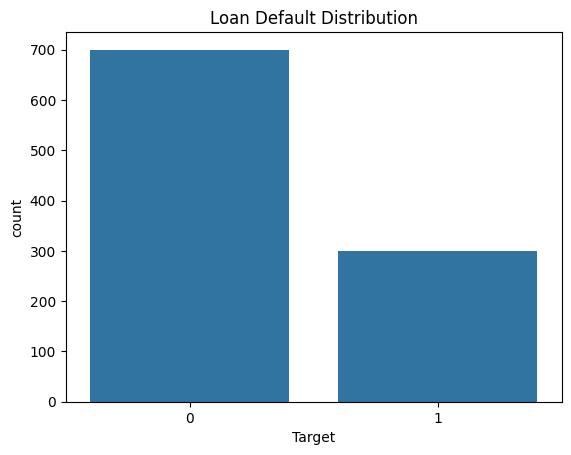

In [34]:
sns.countplot(x="Target", data=df)

plt.title("Loan Default Distribution")

plt.show()

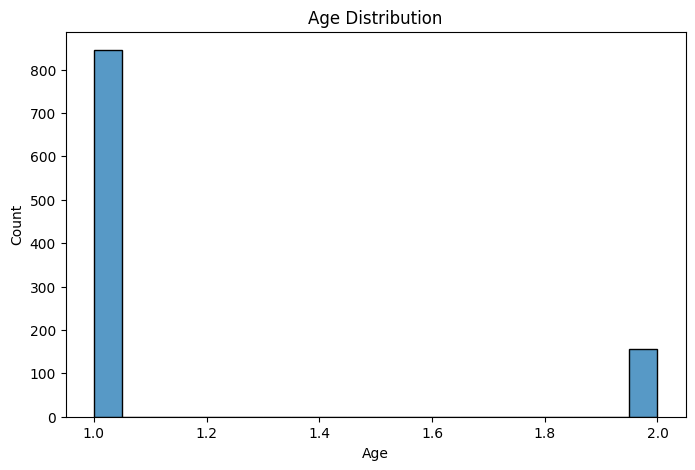

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.show()

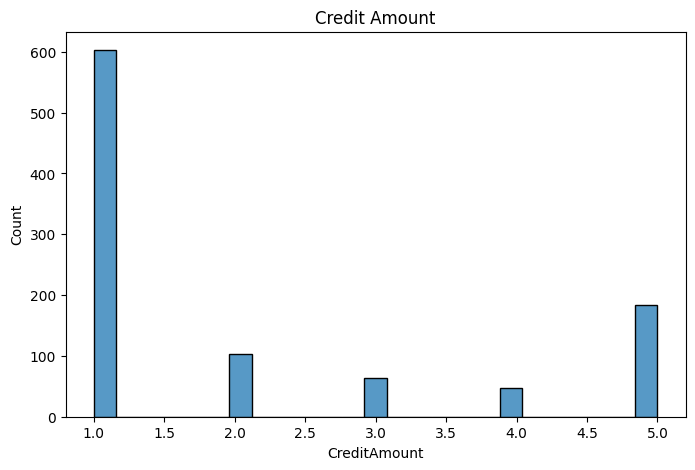

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df["CreditAmount"], bins=25)

plt.title("Credit Amount")

plt.show()

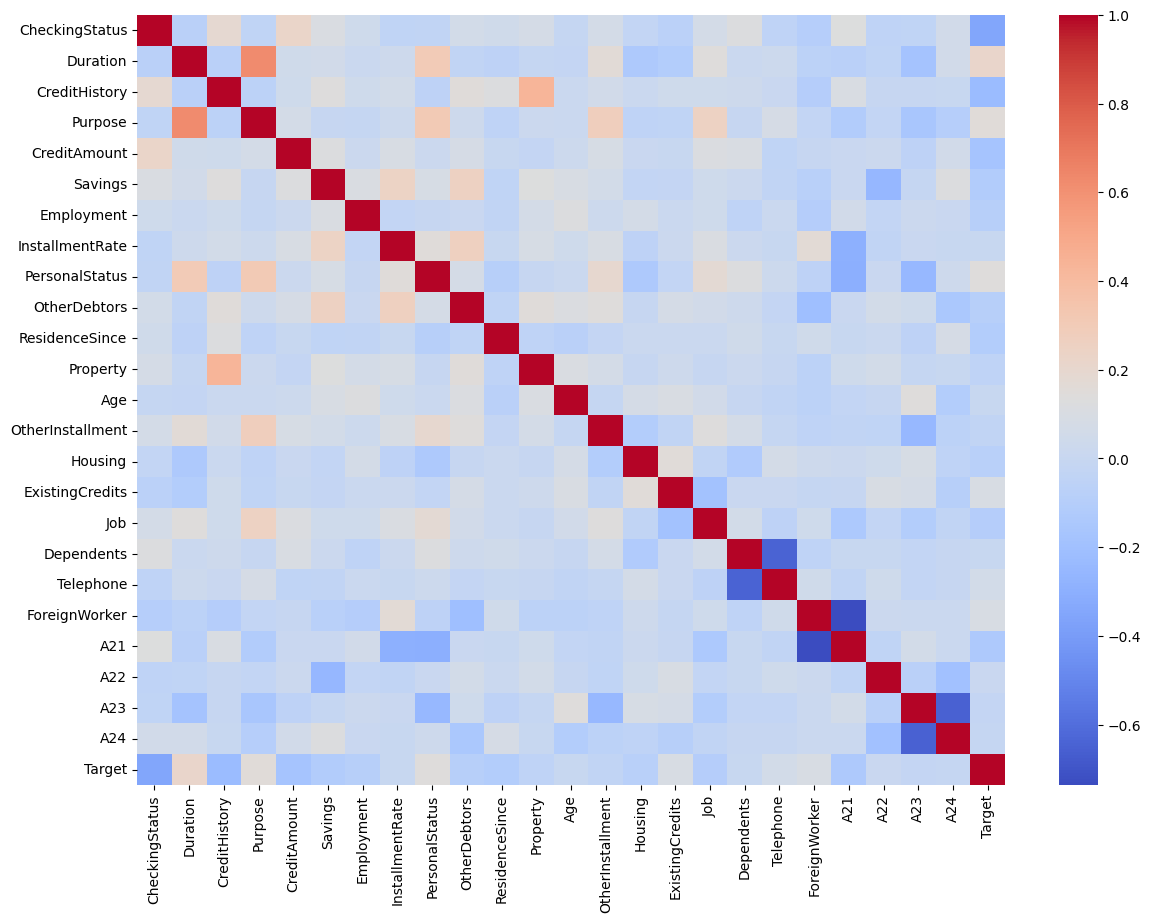

In [37]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.show()

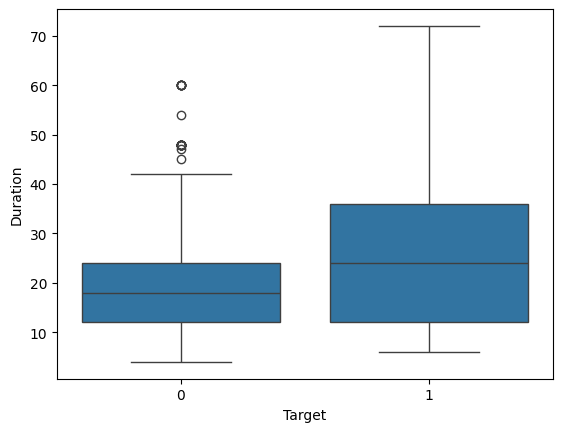

In [38]:
sns.boxplot(
    x="Target",
    y="Duration",
    data=df
)

plt.show()

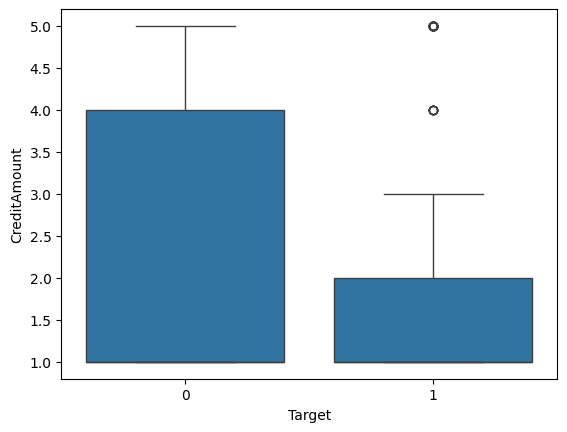

In [39]:
sns.boxplot(
    x="Target",
    y="CreditAmount",
    data=df
)

plt.show()

In [40]:
X = df.drop("Target", axis=1)

y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [41]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [42]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy")

print(accuracy_score(y_test,pred_lr))

print(classification_report(y_test,pred_lr))

Accuracy
0.775
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       141
           1       0.65      0.51      0.57        59

    accuracy                           0.78       200
   macro avg       0.73      0.70      0.71       200
weighted avg       0.76      0.78      0.77       200



In [43]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print(accuracy_score(y_test,pred_dt))

0.665


In [44]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42

)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print(accuracy_score(y_test,pred_rf))

0.795


In [45]:
knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

pred_knn = knn.predict(X_test)

print(accuracy_score(y_test,pred_knn))

0.745


In [46]:
svm = SVC(probability=True)

svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)

print(accuracy_score(y_test,pred_svm))

0.79


In [47]:
accuracy = {

    "Logistic Regression":accuracy_score(y_test,pred_lr),

    "Decision Tree":accuracy_score(y_test,pred_dt),

    "Random Forest":accuracy_score(y_test,pred_rf),

    "KNN":accuracy_score(y_test,pred_knn),

    "SVM":accuracy_score(y_test,pred_svm)

}

comparison = pd.DataFrame(

    accuracy.items(),

    columns=["Model","Accuracy"]

)

print(comparison.sort_values(

    by="Accuracy",

    ascending=False

))

                 Model  Accuracy
2        Random Forest     0.795
4                  SVM     0.790
0  Logistic Regression     0.775
3                  KNN     0.745
1        Decision Tree     0.665


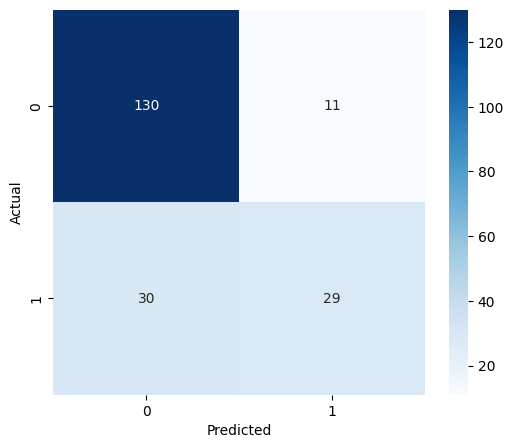

In [48]:
cm = confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

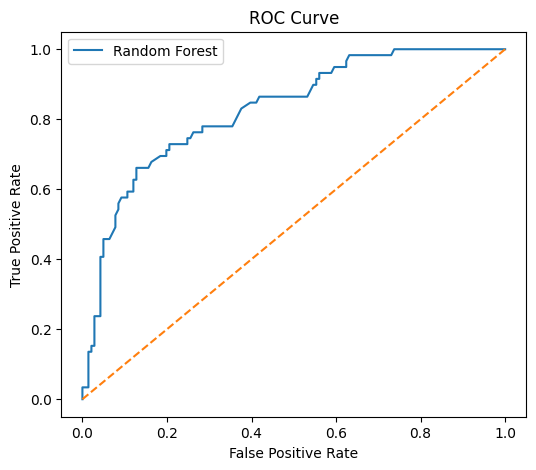

ROC AUC = 0.8275634090635894


In [49]:
prob = rf.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,prob)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("ROC AUC =",roc_auc_score(y_test,prob))

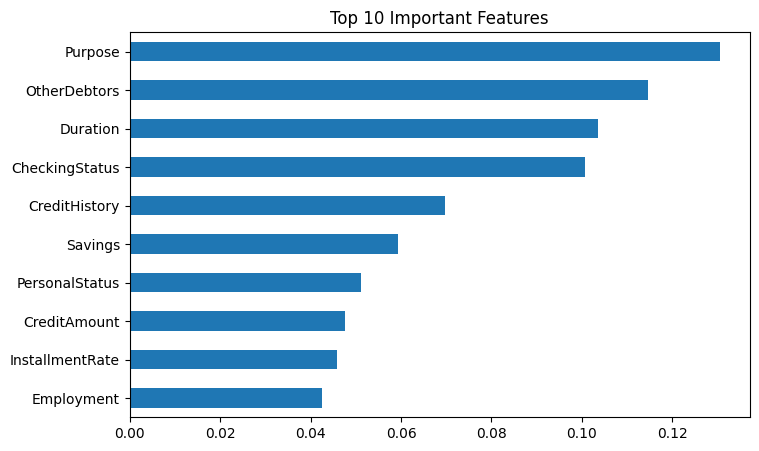

In [50]:
importance = pd.Series(

    rf.feature_importances_,

    index=X.columns

)

importance.sort_values().tail(10).plot(

    kind="barh",

    figsize=(8,5)

)

plt.title("Top 10 Important Features")

plt.show()

In [51]:
sample = X.iloc[[0]]

sample = scaler.transform(sample)

prediction = rf.predict(sample)

if prediction[0] == 0:
    print("Good Credit Risk")
else:
    print("Bad Credit Risk")

Good Credit Risk
